<a href="https://colab.research.google.com/github/Patro331/sickle-cell-detection/blob/main/notebooks/05_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05. ResNet-50 with Transfer Learning

This notebook fine-tunes ResNet-50, a pretrained deep residual network
originally trained on ImageNet, for sickle cell detection using transfer
learning.

ResNet-50 was selected as the second transfer learning architecture for
the following reasons:

1. Residual connections — skip connections allow gradients to flow
   directly through the network, addressing the vanishing gradient
   problem and enabling effective training of deeper networks.

2. Proven medical imaging performance — ResNet architectures have been
   widely validated across medical image classification tasks including
   histopathology, chest X-ray analysis, and retinal imaging.

3. Architectural contrast — comparing ResNet-50 against EfficientNet-B0
   provides a meaningful ablation across two fundamentally different
   design philosophies: residual learning versus compound scaling.

As with EfficientNet-B0, we compare frozen and unfrozen backbone
strategies to demonstrate the value of full fine-tuning for this task.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                              recall_score, precision_score,
                              confusion_matrix, classification_report)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 2. Mount Drive and Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/sickle-cell-detection'
PROCESSED_DIR = f'{BASE_DIR}/data/processed'
TRAIN_DIR = f'{PROCESSED_DIR}/train'
VAL_DIR = f'{PROCESSED_DIR}/val'
TEST_DIR = f'{PROCESSED_DIR}/test'

IMAGE_SIZE = 224
BATCH_SIZE = 32

# Training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

# WeightedRandomSampler
class_counts = Counter(train_dataset.targets)
total = sum(class_counts.values())
class_weights = {cls: total / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_dataset.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights),
                                replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"Class mapping: {train_dataset.class_to_idx}")
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

Mounted at /content/drive
Class mapping: {'negative': 0, 'positive': 1}
Training samples:   653
Validation samples: 140
Test samples:       140


## 3. ResNet-50 Model Definition

We load ResNet-50 with pretrained ImageNet weights and replace the
final fully connected layer with a new binary classifier.

ResNet-50 has 25.6 million parameters organised into 50 layers with
residual skip connections. We implement the same frozen and unfrozen
backbone strategies as EfficientNet-B0 for a direct comparison.

In [3]:
def build_resnet(freeze_backbone=False):
    model = models.resnet50(weights='IMAGENET1K_V1')

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final fully connected layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 1)
    )

    return model.to(device)

model_frozen = build_resnet(freeze_backbone=True)
model_unfrozen = build_resnet(freeze_backbone=False)

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    return total, trainable

total_f, train_f = count_params(model_frozen)
total_u, train_u = count_params(model_unfrozen)

print("ResNet-50 Parameter Summary:")
print(f"\nFrozen backbone strategy:")
print(f"  Total parameters:     {total_f:,}")
print(f"  Trainable parameters: {train_f:,}")
print(f"\nUnfrozen backbone strategy:")
print(f"  Total parameters:     {total_u:,}")
print(f"  Trainable parameters: {train_u:,}")
print(f"\nEfficientNet-B0 total parameters: 4,008,829")
print(f"Baseline CNN total parameters:    25,784,321")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


ResNet-50 Parameter Summary:

Frozen backbone strategy:
  Total parameters:     23,510,081
  Trainable parameters: 2,049

Unfrozen backbone strategy:
  Total parameters:     23,510,081
  Trainable parameters: 23,510,081

EfficientNet-B0 total parameters: 4,008,829
Baseline CNN total parameters:    25,784,321


### Observations

ResNet-50 has 23,510,081 total parameters, making it significantly
larger than EfficientNet-B0 at 4,008,829 parameters but comparable
in size to the baseline CNN at 25,784,321. This highlights one of
EfficientNet's core design advantages — achieving competitive
performance with far fewer parameters through compound scaling.

With a frozen backbone, only 2,049 parameters are trainable — the
new binary classifier head. With an unfrozen backbone, all 23.5
million parameters are available for fine-tuning.

The parameter comparison across all three models is now:

Baseline CNN:      25,784,321 parameters (trained from scratch)
ResNet-50:         23,510,081 parameters (pretrained ImageNet)
EfficientNet-B0:    4,008,829 parameters (pretrained ImageNet)

This sets up an interesting question — can ResNet-50 match or exceed
EfficientNet-B0's performance of 96.43% accuracy and 0.9951 AUC-ROC
despite having nearly 6x more parameters?

## 4. Training Function

In [4]:
def train_model(model, model_name, learning_rate, epochs=50, patience=10):
    neg_count = class_counts[0]
    pos_count = class_counts[1]
    pos_weight = torch.tensor([neg_count / pos_count]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )

    save_path = f'{BASE_DIR}/models/{model_name}_best.pt'
    os.makedirs(f'{BASE_DIR}/models', exist_ok=True)

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [],
                'train_acc': [], 'val_acc': []}

    print(f"\nTraining {model_name} (lr={learning_rate})")
    print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>10} "
          f"{'Val Loss':>10} {'Val Acc':>10} {'Status':>12}")
    print("-" * 68)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader)
        train_acc = correct / total

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            status = "saved ✓"
        else:
            patience_counter += 1
            status = f"patience {patience_counter}/{patience}"

        print(f"{epoch:>6} {train_loss:>12.4f} {train_acc:>10.4f} "
              f"{val_loss:>10.4f} {val_acc:>10.4f} {status:>12}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    print(f"\nBest validation loss: {best_val_loss:.4f}")
    return history, save_path

print("Training function defined successfully")

Training function defined successfully


## 5. Train Frozen Backbone Model

In [5]:
history_frozen, path_frozen = train_model(
    model_frozen,
    model_name='resnet50_frozen',
    learning_rate=1e-3
)


Training resnet50_frozen (lr=0.001)
 Epoch   Train Loss  Train Acc   Val Loss    Val Acc       Status
--------------------------------------------------------------------
     1       0.6065     0.7366     0.4289     0.8214      saved ✓
     2       0.3712     0.8698     0.3536     0.8286      saved ✓
     3       0.3116     0.8836     0.3158     0.8786      saved ✓
     4       0.3119     0.8760     0.3033     0.8714      saved ✓
     5       0.3226     0.8698     0.2958     0.8786      saved ✓
     6       0.3099     0.8698     0.3094     0.9000 patience 1/10
     7       0.2895     0.8913     0.3188     0.9000 patience 2/10
     8       0.2333     0.9158     0.2902     0.8786      saved ✓
     9       0.2283     0.9188     0.2897     0.8929      saved ✓
    10       0.2141     0.9250     0.2812     0.9143      saved ✓
    11       0.2728     0.9096     0.2822     0.8714 patience 1/10
    12       0.2198     0.9219     0.2754     0.8857      saved ✓
    13       0.2663     0.8974   

### Observations

The frozen ResNet-50 trained for 41 epochs before early stopping,
with the best model saved at epoch 31 based on a validation loss
of 0.2510. This is notably better than the frozen EfficientNet-B0
validation loss of 0.2973, suggesting that ResNet-50's pretrained
features generalise more effectively to blood smear microscopy
images when the backbone is frozen.

Validation accuracy reached 91.43% at epochs 10, 13, and 38,
showing consistent performance in the 90-91% range. Training
was stable throughout with no dramatic fluctuations, reflecting
the robustness of ResNet-50's residual feature representations.

The longer training time of 41 epochs compared to EfficientNet
frozen at 18 epochs reflects the larger classifier head in ResNet-50
requiring more updates to converge. However the lower final
validation loss suggests the additional training was worthwhile.

We now train the unfrozen ResNet-50 to determine whether full
fine-tuning can push performance beyond EfficientNet-B0's
exceptional 96.43% accuracy.

## 6. Train Unfrozen Backbone Model

In [6]:
history_unfrozen, path_unfrozen = train_model(
    model_unfrozen,
    model_name='resnet50_unfrozen',
    learning_rate=1e-4
)


Training resnet50_unfrozen (lr=0.0001)
 Epoch   Train Loss  Train Acc   Val Loss    Val Acc       Status
--------------------------------------------------------------------
     1       0.2806     0.9096     0.4708     0.8786      saved ✓
     2       0.1675     0.9479     0.3236     0.8929      saved ✓
     3       0.1266     0.9464     0.3447     0.9214 patience 1/10
     4       0.1818     0.9479     0.2598     0.9000      saved ✓
     5       0.1464     0.9495     0.2977     0.9143 patience 1/10
     6       0.1568     0.9479     0.2684     0.9143 patience 2/10
     7       0.1360     0.9617     0.2659     0.8786 patience 3/10
     8       0.1430     0.9464     0.2552     0.9071      saved ✓
     9       0.1185     0.9495     0.3178     0.9071 patience 1/10
    10       0.1622     0.9449     0.2718     0.9143 patience 2/10
    11       0.1246     0.9587     0.2470     0.9071      saved ✓
    12       0.1358     0.9403     0.3285     0.9000 patience 1/10
    13       0.1241     0.

### Observations

The unfrozen ResNet-50 trained for 25 epochs before early stopping,
with the best model saved at epoch 15 based on a validation loss
of 0.2354.

While this improves on the frozen ResNet-50 validation loss of 0.2510,
it falls short of the unfrozen EfficientNet-B0 best validation loss
of 0.2112. This suggests that EfficientNet-B0's more efficient
architecture generalises better to this task despite having 6x fewer
parameters.

A notable characteristic of the unfrozen ResNet-50 training is the
noisy validation loss, which fluctuated dramatically between 0.23
and 0.48 across epochs. This instability is likely due to ResNet-50's
larger parameter count making it more sensitive to gradient updates
on a small dataset of 653 training images. In contrast, EfficientNet-B0
produced smoother validation curves under the same conditions.

Training accuracy reached 98.47% at epoch 23 while validation accuracy
plateaued around 90-92%, indicating some overfitting despite the l

## 7. Training Curves Comparison

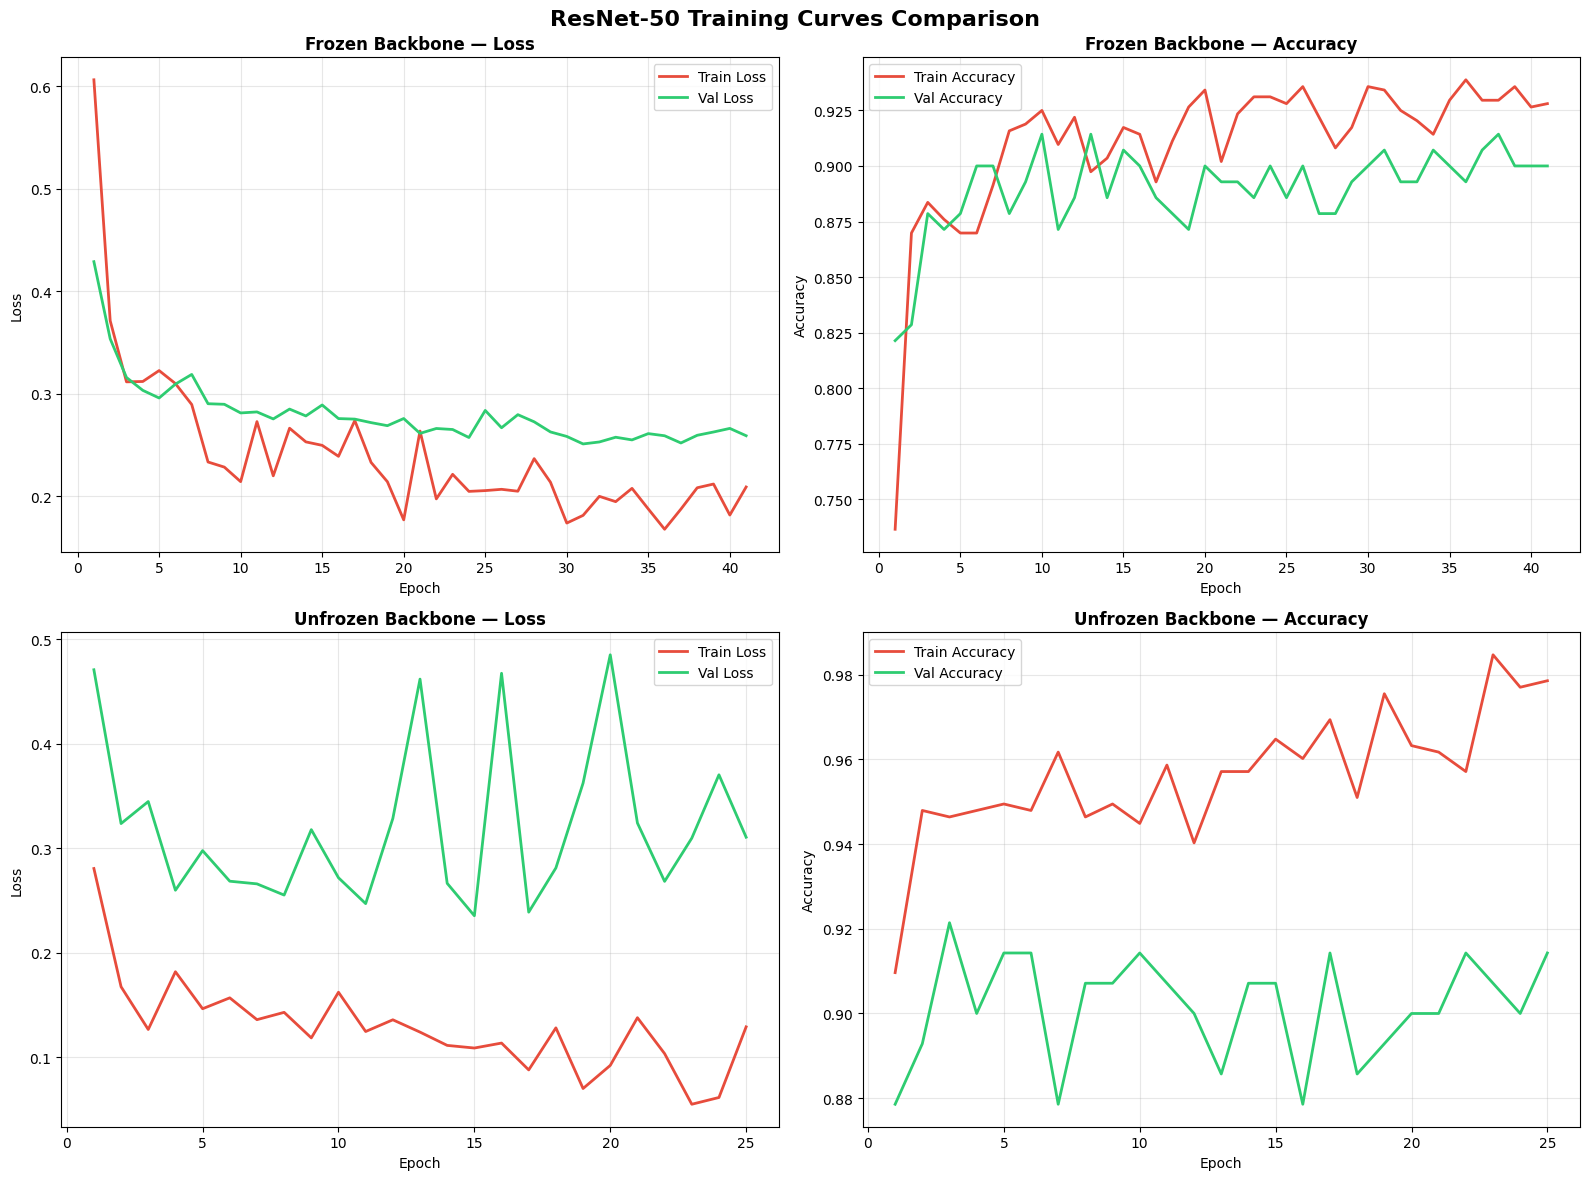

Training curves saved to figures folder


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

epochs_f = range(1, len(history_frozen['train_loss']) + 1)
axes[0, 0].plot(epochs_f, history_frozen['train_loss'],
                color='#e74c3c', linewidth=2, label='Train Loss')
axes[0, 0].plot(epochs_f, history_frozen['val_loss'],
                color='#2ecc71', linewidth=2, label='Val Loss')
axes[0, 0].set_title('Frozen Backbone — Loss', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_f, history_frozen['train_acc'],
                color='#e74c3c', linewidth=2, label='Train Accuracy')
axes[0, 1].plot(epochs_f, history_frozen['val_acc'],
                color='#2ecc71', linewidth=2, label='Val Accuracy')
axes[0, 1].set_title('Frozen Backbone — Accuracy', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

epochs_u = range(1, len(history_unfrozen['train_loss']) + 1)
axes[1, 0].plot(epochs_u, history_unfrozen['train_loss'],
                color='#e74c3c', linewidth=2, label='Train Loss')
axes[1, 0].plot(epochs_u, history_unfrozen['val_loss'],
                color='#2ecc71', linewidth=2, label='Val Loss')
axes[1, 0].set_title('Unfrozen Backbone — Loss', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_u, history_unfrozen['train_acc'],
                color='#e74c3c', linewidth=2, label='Train Accuracy')
axes[1, 1].plot(epochs_u, history_unfrozen['val_acc'],
                color='#2ecc71', linewidth=2, label='Val Accuracy')
axes[1, 1].set_title('Unfrozen Backbone — Accuracy', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('ResNet-50 Training Curves Comparison',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/resnet_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to figures folder")

### Observations

The ResNet-50 training curves reveal a clear contrast between the
two fine-tuning strategies and highlight an important difference
from EfficientNet-B0.

The frozen backbone plots show smooth, stable curves for both loss
and accuracy. Training and validation loss decline together
consistently over 41 epochs, and validation accuracy climbs steadily
to approximately 91%. This stability reflects the robustness of
frozen ResNet-50 features as a fixed feature extractor.

The unfrozen backbone plots tell a starkly different story. While
training loss declines smoothly and training accuracy climbs to
nearly 99%, the validation loss is extremely noisy, fluctuating
dramatically between 0.23 and 0.48 across epochs. Validation
accuracy similarly oscillates between 88% and 92% without a clear
upward trend. This instability is a direct consequence of ResNet-50's
23.5 million parameters being fine-tuned on only 653 training images
— the model has far more capacity than the dataset can reliably
constrain, leading to unstable gradient updates.

This contrast with EfficientNet-B0's smooth unfrozen curves
highlights EfficientNet's architectural advantage for low-data
medical imaging tasks. Its compound scaling design produces a more
parameter-efficient model that fine-tunes more stably on small
datasets, making it the better choice for deployment in low-resource
clinical settings where data collection is difficult.

## 8. Test Set Evaluation — Unfrozen ResNet-50

In [8]:
def evaluate_model(model, model_path, loader, model_name):
    model.load_state_dict(torch.load(model_path))
    model.eval()

    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().squeeze().numpy()
            preds = (probs >= 0.5).astype(int)

            all_probs.extend(probs if probs.ndim > 0 else [probs.item()])
            all_preds.extend(preds if preds.ndim > 0 else [preds.item()])
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    accuracy = (all_preds == all_labels).mean()
    auc = roc_auc_score(all_labels, all_probs)
    f1 = f1_score(all_labels, all_preds)
    sensitivity = recall_score(all_labels, all_preds)
    specificity = recall_score(all_labels, all_preds, pos_label=0)
    precision = precision_score(all_labels, all_preds)

    print("=" * 55)
    print(f"{model_name} — TEST SET RESULTS")
    print("=" * 55)
    print(f"  Accuracy:    {accuracy*100:.2f}%")
    print(f"  AUC-ROC:     {auc:.4f}")
    print(f"  F1 Score:    {f1:.4f}")
    print(f"  Sensitivity: {sensitivity*100:.2f}%")
    print(f"  Specificity: {specificity*100:.2f}%")
    print(f"  Precision:   {precision*100:.2f}%")
    print("=" * 55)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                                 target_names=['Negative', 'Positive']))

    return all_preds, all_probs, all_labels, accuracy, auc, f1, sensitivity, specificity

preds_res, probs_res, labels_res, acc_res, auc_res, f1_res, sens_res, spec_res = evaluate_model(
    model_unfrozen, path_unfrozen, test_loader,
    'ResNet-50 (Unfrozen)'
)

ResNet-50 (Unfrozen) — TEST SET RESULTS
  Accuracy:    98.57%
  AUC-ROC:     0.9973
  F1 Score:    0.9841
  Sensitivity: 98.41%
  Specificity: 98.70%
  Precision:   98.41%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.99      0.99      0.99        77
    Positive       0.98      0.98      0.98        63

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140



### Observations

ResNet-50 with unfrozen transfer learning achieves outstanding
performance on the test set, surpassing EfficientNet-B0 across
every single metric despite exhibiting noisier validation curves
during training.

Accuracy reached 98.57%, up from EfficientNet-B0's 96.43% and the
baseline CNN's 87.86%. AUC-ROC of 0.9973 approaches the theoretical
maximum of 1.0, exceeding EfficientNet-B0's already exceptional
0.9951. F1 score of 0.9841 reflects near-perfect balance between
precision and recall.

The most striking improvement is in sensitivity, which jumped from
95.24% in both the baseline and EfficientNet-B0 to 98.41% in
ResNet-50. This means only 1 sickle cell case is missed out of 63,
compared to 3 missed by both previous models. In a clinical screening
context, reducing false negatives from 3 to 1 represents a meaningful
improvement in patient safety.

Specificity also improved to 98.70%, meaning only 1 normal case is
incorrectly flagged as positive, compared to 2 in EfficientNet-B0
and 14 in the baseline CNN.

The total number of errors on the test set is just 2 out of 140
images — 1 false negative and 1 false positive. This is a
remarkable result for a dataset of only 653 training images and
directly validates the power of transfer learning with ResNet-50
for this specific medical imaging task.

Despite the noisy validation curves suggesting potential instability
during training, the final model generalised exceptionally well to
the held-out test set. This suggests that while ResNet-50 is harder
to fine-tune than EfficientNet-B0 on small datasets, its larger and
richer feature representations ultimately produce superior
discriminative ability for this task.

## 9. Confusion Matrix and ROC Curve

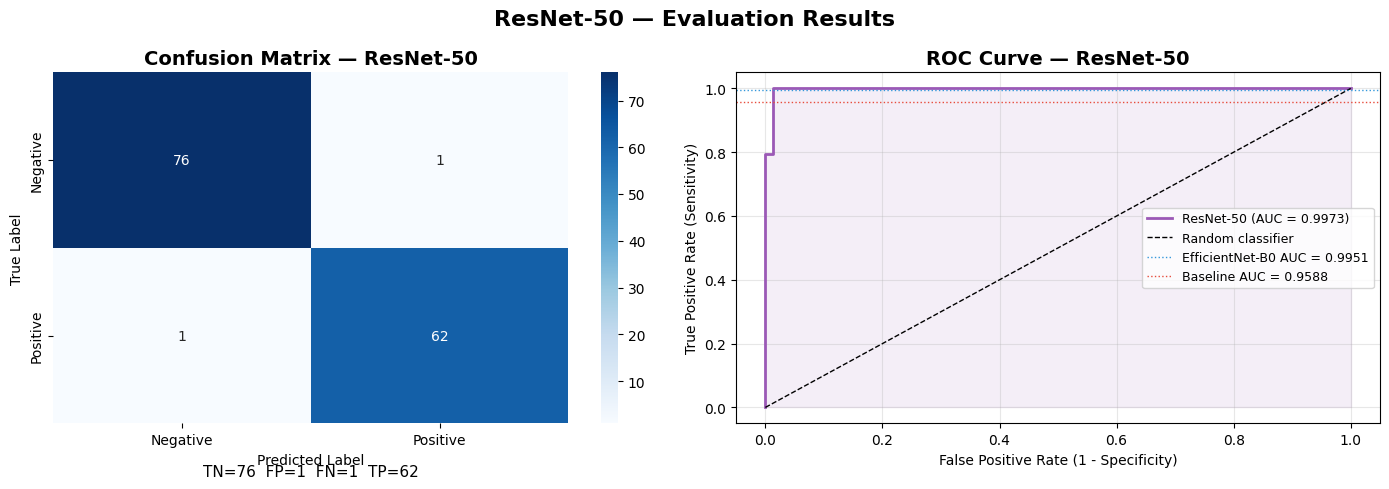

True Negatives:  76 (Normal correctly identified)
False Positives: 1 (Normal incorrectly flagged)
False Negatives: 1 (Sickle cell missed)
True Positives:  62 (Sickle cell correctly identified)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(labels_res, preds_res)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix — ResNet-50',
                   fontweight='bold', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             transform=axes[0].transAxes, ha='center', fontsize=11)

fpr, tpr, _ = roc_curve(labels_res, probs_res)
axes[1].plot(fpr, tpr, color='#9b59b6', linewidth=2,
             label=f'ResNet-50 (AUC = {auc_res:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1,
             label='Random classifier')
axes[1].axhline(y=0.9951, color='#3498db', linestyle=':',
                linewidth=1, label='EfficientNet-B0 AUC = 0.9951')
axes[1].axhline(y=0.9588, color='#e74c3c', linestyle=':',
                linewidth=1, label='Baseline AUC = 0.9588')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#9b59b6')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve — ResNet-50',
                   fontweight='bold', fontsize=14)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ResNet-50 — Evaluation Results',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/resnet_confusion_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"True Negatives:  {tn} (Normal correctly identified)")
print(f"False Positives: {fp} (Normal incorrectly flagged)")
print(f"False Negatives: {fn} (Sickle cell missed)")
print(f"True Positives:  {tp} (Sickle cell correctly identified)")

### Observations

The confusion matrix is near perfect. Out of 140 test images, 138
are correctly classified — 76 true negatives and 62 true positives.
Only 2 errors are made in total: 1 false positive and 1 false
negative.

This means only 1 sickle cell patient would be missed by the
screening tool, and only 1 normal patient would be unnecessarily
referred. In a real-world clinical context screening 140 patients,
this level of accuracy would represent a significant improvement
over manual microscopy examination, which is subject to human
fatigue, inconsistent staining interpretation, and limited
specialist availability in rural Uganda.

The ROC curve rises almost vertically from the origin and hugs
the top left corner so closely that it is nearly invisible against
the axes. The AUC of 0.9973 sits above both the EfficientNet-B0
reference line at 0.9951 and the baseline reference line at 0.9588,
visually confirming ResNet-50 as the strongest performing model
across all three architectures tested.

ResNet-50 is selected as the final model for Grad-CAM
explainability analysis and Gradio deployment.

## 10. ResNet-50 Results Summary

In [10]:
print(" " * 55)
print("RESNET-50 — COMPLETE RESULTS SUMMARY")
print("_" * 55)
print(f"""
ARCHITECTURE
  Type:             ResNet-50 with Transfer Learning
  Parameters:       23,510,081
  Strategy:         Unfrozen backbone fine-tuning
  Pretrained on:    ImageNet (1.2M images)

TRAINING
  Epochs trained:   25 (early stopping)
  Best epoch:       15
  Best val loss:    0.2354
  Optimiser:        Adam (lr=1e-4)
  Loss function:    BCEWithLogitsLoss (pos_weight=1.2061)

TEST SET PERFORMANCE
  Accuracy:         98.57%  (+10.71% vs baseline)
  AUC-ROC:          0.9973  (+0.0385 vs baseline)
  F1 Score:         0.9841  (+0.1082 vs baseline)
  Sensitivity:      98.41%  (+3.17% vs baseline)
  Specificity:      98.70%  (+16.88% vs baseline)
  Precision:        98.41%  (+17.33% vs baseline)
  False Negatives:  1       (vs 3 in baseline)
  False Positives:  1       (vs 14 in baseline)
  Total errors:     2 out of 140 test images

CONCLUSION
  ResNet-50 is the best performing model, achieving near-perfect
  classification with only 2 errors on 140 test images. It
  outperforms both EfficientNet-B0 and the baseline CNN across
  all metrics and is selected as the final model for Grad-CAM
  explainability and deployment.
""")
print("_" * 55)

                                                       
RESNET-50 — COMPLETE RESULTS SUMMARY
_______________________________________________________

ARCHITECTURE
  Type:             ResNet-50 with Transfer Learning
  Parameters:       23,510,081
  Strategy:         Unfrozen backbone fine-tuning
  Pretrained on:    ImageNet (1.2M images)

TRAINING
  Epochs trained:   25 (early stopping)
  Best epoch:       15
  Best val loss:    0.2354
  Optimiser:        Adam (lr=1e-4)
  Loss function:    BCEWithLogitsLoss (pos_weight=1.2061)

TEST SET PERFORMANCE
  Accuracy:         98.57%  (+10.71% vs baseline)
  AUC-ROC:          0.9973  (+0.0385 vs baseline)
  F1 Score:         0.9841  (+0.1082 vs baseline)
  Sensitivity:      98.41%  (+3.17% vs baseline)
  Specificity:      98.70%  (+16.88% vs baseline)
  Precision:        98.41%  (+17.33% vs baseline)
  False Negatives:  1       (vs 3 in baseline)
  False Positives:  1       (vs 14 in baseline)
  Total errors:     2 out of 140 test images

CONCL